#### Exercise 10 - Starter - Synthetic Control Using Lasso

An e-commerce company operating in 10 different regions implemented a new marketing strategy in a single test region (Region 5) starting October 1 2024 continuing indefinitely. As we've generated the data ourselves, we know the ground truth is that the treatment increased revenue in that region by 20% over what it would have been if not for the change. 

Your goal is to build a synthetic control model that reasonably reflects this increase. 

In [1]:
# TO-DO: Import pandas, matplotlib.pyplot, and LassoCV from sklearn.linear_model 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
import statsmodels.formula.api as smf

In [2]:
# TO-DO: Read in CSV file called "synthetic_control_revenue_data.csv" 

df = pd.read_csv('https://raw.githubusercontent.com/udacity/causal-inference-foundations/refs/heads/main/Exercise10-synthetic-control/data/synthetic_control_revenue_data.csv', parse_dates=['Month'])
df.head()

,Month,Region 1,Region 2,Region 3,Region 4,Region 5,Region 6,Region 7,Region 8,Region 9,Region 10
0,2023-01-01,9322.565026,10763.201411,8379.885931,9258.455623,9450.947929,10437.677905,10060.643647,9985.189491,9328.222526,9639.947623
1,2023-02-01,9737.938268,11701.398724,11241.961029,10991.843109,10222.822882,10700.643686,10281.504076,10915.543547,10560.931888,11581.508977
2,2023-03-01,11287.917691,11792.099443,11363.351753,9207.389538,10847.371295,11319.571857,12205.977940,12243.919931,10102.988763,11022.111375
3,2023-04-01,12584.751131,12967.746822,12867.541821,11259.416674,11975.964764,12603.817098,11528.820985,11631.156162,11660.287992,12052.554474
4,2023-05-01,11816.404647,11426.054667,11258.764335,11598.348889,11540.803870,12154.049899,10765.484396,12401.222295,11194.799213,11972.444224


In [3]:
print(df['Month'].min())
print(df['Month'].max())

2023-01-01 00:00:00
2024-12-01 00:00:00


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Month      24 non-null     datetime64[ns]
 1   Region 1   24 non-null     float64       
 2   Region 2   24 non-null     float64       
 3   Region 3   24 non-null     float64       
 4   Region 4   24 non-null     float64       
 5   Region 5   24 non-null     float64       
 6   Region 6   24 non-null     float64       
 7   Region 7   24 non-null     float64       
 8   Region 8   24 non-null     float64       
 9   Region 9   24 non-null     float64       
 10  Region 10  24 non-null     float64       
dtypes: datetime64[ns](1), float64(10)
memory usage: 2.2 KB


In [5]:
# Set parameters 
event_start = "2024-10-01" 
treated_region = "Region 5"
# To-DO: List of all regions except the treated region 
control_regions = list(df.filter(regex='Region*').columns.drop(treated_region))

In [6]:
# Estimate a Lasso regression model using all pre-treatment data 
# TO-DO: Filter for pre-treatment data 
preperiod = df[df['Month']<pd.to_datetime(event_start)]

# Initialize Lasso model with a regularization parameter (in the future, you may want to tune this parameter)
lasso_model = LassoCV(cv=5, random_state=42)

# TO-DO: Fit the lasso model, save and print the coefficients
lasso_model.fit(preperiod[control_regions], preperiod[treated_region])
lasso_coefficients = pd.Series(lasso_model.coef_, index=control_regions)
print(lasso_coefficients)

Region 1     0.499141
Region 2     0.000000
Region 3     0.001292
Region 4     0.298641
Region 6     0.000303
Region 7     0.198430
Region 8     0.000000
Region 9     0.000000
Region 10    0.000083
dtype: float64


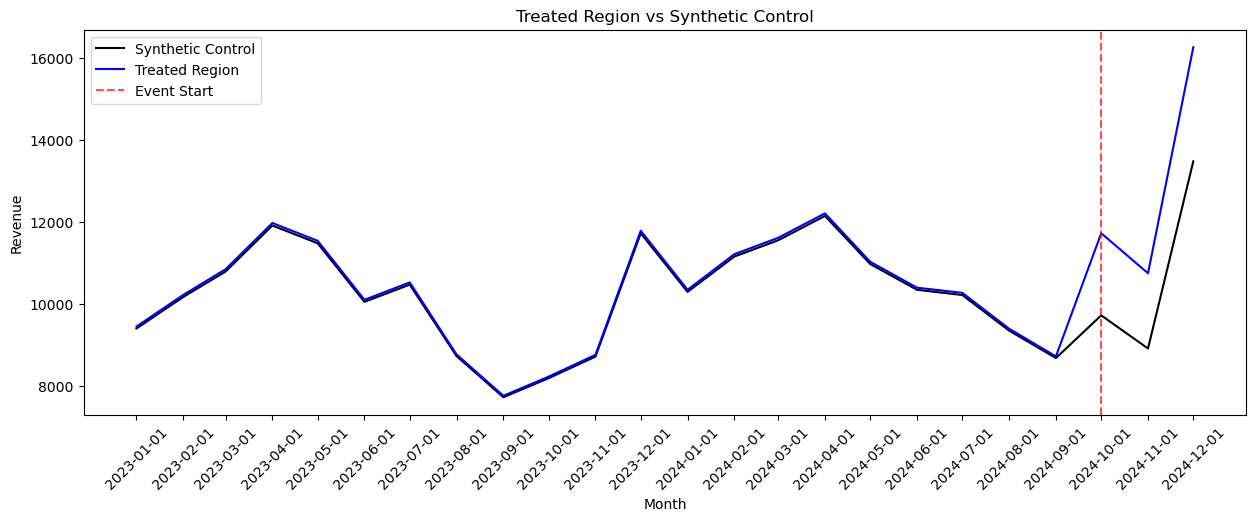

In [7]:
# Use the coefficients to estimate the synthetic control for the entire period 
# HINT: Use the dot product of the control regions and the lasso coefficients 

df["Synthetic Control"] = df[control_regions].dot(lasso_coefficients)+ lasso_model.intercept_

# Plot the treated region and synthetic control
# HINT: The synthetic control may be directly on top of the treated region, 
#       Offsetting by a small amount can help visualize that they are two separate lines 
offset_for_plot=0.995

plt.figure(figsize=(15, 5))
plt.plot(df['Month'], df['Synthetic Control']*offset_for_plot, label='Synthetic Control', color='k')
plt.plot(df['Month'], df[treated_region], label='Treated Region', color='b')
plt.xticks(df['Month'], rotation=45)
plt.axvline(pd.to_datetime(event_start), linestyle='--', color='r', alpha=0.7, label='Event Start')
plt.legend(loc='upper left')
plt.title('Treated Region vs Synthetic Control')
plt.ylabel('Revenue')
plt.xlabel('Month')
plt.show()

In [8]:
# TO-DO: Calculate the treatment effect as the difference between the treated region and the synthetic control 
df["Treatment Effect"] = df[treated_region] - df['Synthetic Control']

# TO-DO: Calculate the average monthly treatment effect in the post-treatment period: 
# How does this compare to the value the treated region would have had without the intervention?  
postperiod = df[df['Month']>=pd.to_datetime(event_start)]
print(postperiod['Treatment Effect'].mean())
print(postperiod['Treatment Effect'].mean()/postperiod['Synthetic Control'].mean())

2152.6534658553196
0.20006258909742863


### Check if there is a difference in the preperiod mean:
If there is a meaningful preperiod gap, we can adjust estimates using a difference in differences approach

- This is not always necessary, but can be useful if there are differences in the preperiod means.
- This is a simple check and not a formal statistical test. You still need to run permutation tests to assess significance.
- In this case, there is no meaningful difference in the preperiod means, so this step is not necessary.
- A meaningfully large preperiod gap could also be a red flag that you have a poor synthetic control. Tread carefully.

In [9]:
preperiod=df[df['Month']<pd.to_datetime(event_start)]
print(preperiod['Synthetic Control'].mean())
print(preperiod[treated_region].mean())

10246.694773644238
10246.69477364424


In [10]:
# TO-DO: Model the treatment effect using a difference-in-differences approach against the synthetic control

# Include the treated region data only 
treated_df = df[['Month', treated_region]].copy()
treated_df.columns=['Month', 'Revenue']
treated_df["treated"] = 1

# Include the synthetic control data only 
control_df = df[['Month','Synthetic Control']].copy()
control_df.columns=['Month', 'Revenue']
control_df["treated"] = 0

stacked_df = pd.concat([treated_df, control_df], ignore_index=True)

# Fit a difference-in-differences model
stacked_df['post']=np.where(stacked_df['Month']>=pd.to_datetime(event_start), 1, 0)
stacked_df['post_treated']=stacked_df['treated']*stacked_df['post']

formula='Revenue~treated+post+post_treated'
did_model=smf.ols(formula=formula, data=stacked_df).fit()
print(did_model.summary())

                            OLS Regression Results                            
Dep. Variable:                Revenue   R-squared:                       0.175
Model:                            OLS   Adj. R-squared:                  0.119
Method:                 Least Squares   F-statistic:                     3.106
Date:                Thu, 04 Dec 2025   Prob (F-statistic):             0.0360
Time:                        13:03:03   Log-Likelihood:                -416.18
No. Observations:                  48   AIC:                             840.4
Df Residuals:                      44   BIC:                             847.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     1.025e+04    321.401     31.881   

In [11]:
# Calculate the average treatment effect on the treated (ATT)
att=did_model.params['post_treated']

postperiod_control_avg=stacked_df[(stacked_df['post']==1)&(stacked_df['treated']==0)]['Revenue'].mean()

att_pct = 100*(att/postperiod_control_avg)
print(f"Estimated Basedline Revenue Y(0): {postperiod_control_avg:.3f}")
# print(f"Estimated Potential Outcome Y(0): {att:.3f}")
print(f"Pct Increase: {att_pct:.2f}%")

Estimated Basedline Revenue Y(0): 10759.900
Pct Increase: 20.01%


## Placebo test to iterate over different untreated group

In [12]:
def get_synthetic_control_estimate(data, control_group, treated_group, event_start):
    preperiod = data[data['Month']<pd.to_datetime(event_start)]

    # Initialize Lasso model with a regularization parameter (in the future, you may want to tune this parameter)
    lasso_model = LassoCV(cv=5).fit(preperiod[control_group], preperiod[treated_group])
    
    # TO-DO: Fit the lasso model, save and print the coefficients
    lasso_coefficients = pd.Series(lasso_model.coef_, index=control_group)

    data['Synthetic Control']=data[control_group].dot(lasso_coefficients)+ lasso_model.intercept_
    data['Treatment Effect']=data[treated_group]-data['Synthetic Control']

    post_att = data[data['Month']>= pd.to_datetime(event_start)]['Treatment Effect'].mean()
    return post_att

In [13]:
get_synthetic_control_estimate(df, control_regions, treated_region, event_start)

2152.6534658553196

### Permutation test, running over each untreated group

In [14]:
synth_att = []
untreated_df = df.drop(columns=[treated_region])

for placebo_region in control_regions:
    new_control=list(untreated_df.filter(regex='Region*').columns.drop(placebo_region))
    syn_att = get_synthetic_control_estimate(untreated_df, new_control, placebo_region, event_start)
    synth_att.append(syn_att)

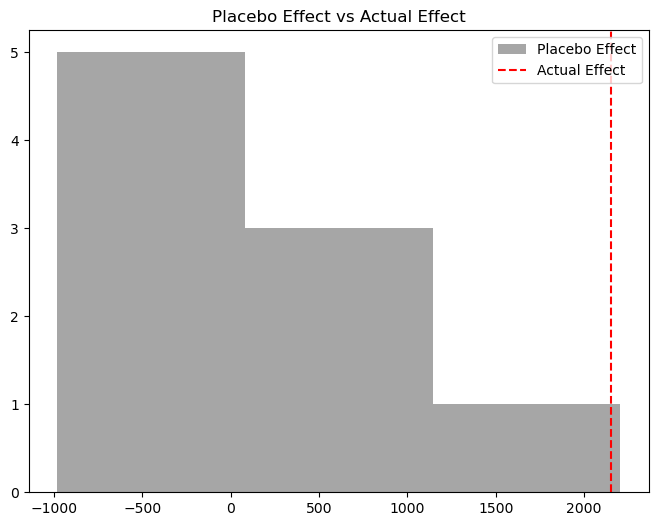

In [15]:
plt.figure(figsize=(8, 6))
plt.hist(synth_att, bins=3, color='gray', alpha=0.7, label='Placebo Effect')
plt.axvline(att, color='r', linestyle='--', label='Actual Effect')
plt.legend(loc='upper right')
plt.title('Placebo Effect vs Actual Effect')
plt.show()

In [16]:
synth_att

[2204.656374044765,
 186.20873601400612,
 231.5077865783081,
 -137.5803436502647,
 -961.3288029615645,
 -403.2474595337414,
 -736.1435356172182,
 -984.0835514874088,
 228.03556168576355]

In [17]:
epirical_p_values = (synth_att>att).sum()/(len(synth_att))
print(f'Epirical P values: {epirical_p_values:.1%}')

Epirical P values: 11.1%


### Empirical p-value based on standardized permutation test statistic

Since we have only 8 groups here, the epirical p values here are pretty large: 11%. 

When there's a very small number of control regions, the p-value based on the empirical ranking may not be particularly useful or descriptive. For example, if there are just 5 permutation tests, then the the only options for the p-value via ranking are 0, 0.2, 0.4, 0.6. 0.8, and 1.0.

In these cases, you can use the mean and standard deviation of these effects to assess significance, but note that this requires stronger assumptions: that the distribution of the permutation tests are normal and that this small sample mean and standard deviation is close estimate of the true population distribution.

In this case, obtain the standardized permutation test statistic by subtracting the sample permutation mean and dividing by the sample permutation standard deviation. Adding and subtracting 1.96*sample std dev gives you something akin to a 95% confidence interval for testing.

Note that inference for small-samples and synthetic controls is a rapidly evolving field and there may be other reasonable techniques.

In [18]:
permutation_mean =  np.mean(synth_att)
permutation_std = np.std(synth_att)
standardized_score = (att - permutation_mean) / permutation_std
print(f"Estimated ATE: {att:.2f}")
print(f"Placebo Mean: {permutation_mean:.2f}, Placebo Std: {permutation_std:.2f}")
print(f"Placebo Confidence Interval: {permutation_mean - 1.96*permutation_std:.2f} to {permutation_mean + 1.96*permutation_std:.2f}")
print(f"Standardized Score: {standardized_score:.2f}")

Estimated ATE: 2152.65
Placebo Mean: -41.33, Placebo Std: 919.02
Placebo Confidence Interval: -1842.61 to 1759.95
Standardized Score: 2.39
